In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/LungTumour"

# Find the zip file
zip_files = [f for f in os.listdir(zip_path) if f.endswith('.zip')]
print("Found zip files:", zip_files)

zip_file = os.path.join(zip_path, zip_files[0])
extract_path = "/content/LIDC-IDRI-slices"

if not os.path.exists(extract_path):
    print(f"Extracting {zip_file} ...")
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(extract_path)
    print("Extraction complete!")
else:
    print("Already extracted, skipping.")

Found zip files: ['dataset.zip']
Extracting /content/drive/MyDrive/LungTumour/dataset.zip ...
Extraction complete!


In [3]:
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Point to extracted folder
DATASET_PATH = "/content/LIDC-IDRI-slices"

# If your zip extracted into a subfolder, auto-detect it
contents = os.listdir(DATASET_PATH)
if len(contents) == 1 and os.path.isdir(os.path.join(DATASET_PATH, contents[0])):
    DATASET_PATH = os.path.join(DATASET_PATH, contents[0])
    print("Adjusted DATASET_PATH to:", DATASET_PATH)
else:
    print("DATASET_PATH:", DATASET_PATH)

print("Sample entries:", os.listdir(DATASET_PATH)[:5])

Adjusted DATASET_PATH to: /content/LIDC-IDRI-slices/LIDC-IDRI-slices
Sample entries: ['LIDC-IDRI-0385', 'LIDC-IDRI-0133', 'LIDC-IDRI-0326', 'LIDC-IDRI-0884', 'LIDC-IDRI-0555']


In [4]:
print("Top-level entries (first 5):")
top_entries = sorted(os.listdir(DATASET_PATH))[:5]
for entry in top_entries:
    print(" ", entry)

sample_patient = top_entries[0]
sample_patient_path = os.path.join(DATASET_PATH, sample_patient)
print(f"\nContents of '{sample_patient}':")
for nodule in sorted(os.listdir(sample_patient_path))[:3]:
    nodule_path = os.path.join(sample_patient_path, nodule)
    print(f"  {nodule}/")
    for item in sorted(os.listdir(nodule_path)):
        item_path = os.path.join(nodule_path, item)
        if os.path.isdir(item_path):
            count = len(os.listdir(item_path))
            print(f"    {item}/  [{count} files]")
        else:
            print(f"    {item}")

Top-level entries (first 5):
  LIDC-IDRI-0001
  LIDC-IDRI-0002
  LIDC-IDRI-0003
  LIDC-IDRI-0004
  LIDC-IDRI-0005

Contents of 'LIDC-IDRI-0001':
  nodule-0/
    images/  [9 files]
    mask-0/  [9 files]
    mask-1/  [9 files]
    mask-2/  [9 files]
    mask-3/  [9 files]


In [5]:
patients = sorted([p for p in os.listdir(DATASET_PATH)
                   if os.path.isdir(os.path.join(DATASET_PATH, p))])

records = []

for patient in tqdm(patients, desc="Scanning dataset"):
    patient_path = os.path.join(DATASET_PATH, patient)
    nodules = sorted(os.listdir(patient_path))

    for nodule in nodules:
        nodule_path = os.path.join(patient_path, nodule)
        if not os.path.isdir(nodule_path):
            continue

        img_folder = os.path.join(nodule_path, "images")
        if not os.path.exists(img_folder):
            continue

        image_files = sorted([f for f in os.listdir(img_folder) if f.endswith(".png")])
        if len(image_files) == 0:
            continue

        mask_folders = sorted([
            os.path.join(nodule_path, m)
            for m in os.listdir(nodule_path)
            if "mask" in m and os.path.isdir(os.path.join(nodule_path, m))
        ])

        records.append({
            "patient":       patient,
            "nodule":        nodule,
            "num_slices":    len(image_files),
            "num_annotators": len(mask_folders),
            "nodule_path":   nodule_path,
            "image_files":   image_files,
            "mask_folders":  mask_folders,
        })

df = pd.DataFrame(records)

print(f"Total Patients         : {df['patient'].nunique()}")
print(f"Total Valid Nodules    : {len(df)}")
print(f"Total Slices           : {df['num_slices'].sum()}")
print(f"Avg Slices per Nodule  : {df['num_slices'].mean():.2f}")
print(f"Avg Annotators/Nodule  : {df['num_annotators'].mean():.2f}")
df.head()

Scanning dataset: 100%|██████████| 875/875 [00:00<00:00, 2448.20it/s]


Total Patients         : 875
Total Valid Nodules    : 2630
Total Slices           : 15548
Avg Slices per Nodule  : 5.91
Avg Annotators/Nodule  : 4.00


,patient,nodule,num_slices,num_annotators,nodule_path,image_files,mask_folders
0,LIDC-IDRI-0001,nodule-0,9,4,/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LID...,"[slice-0.png, slice-1.png, slice-2.png, slice-...",[/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LI...
1,LIDC-IDRI-0002,nodule-0,28,4,/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LID...,"[slice-0.png, slice-1.png, slice-10.png, slice...",[/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LI...
2,LIDC-IDRI-0003,nodule-0,8,4,/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LID...,"[slice-0.png, slice-1.png, slice-2.png, slice-...",[/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LI...
3,LIDC-IDRI-0003,nodule-1,10,4,/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LID...,"[slice-0.png, slice-1.png, slice-2.png, slice-...",[/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LI...
4,LIDC-IDRI-0003,nodule-2,4,4,/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LID...,"[slice-0.png, slice-1.png, slice-2.png, slice-...",[/content/LIDC-IDRI-slices/LIDC-IDRI-slices/LI...


In [6]:
nodules_per_patient = df.groupby('patient').size().reset_index(name='nodule_count')
print(nodules_per_patient['nodule_count'].describe().to_frame().T.to_string())

              count      mean       std  min  25%  50%  75%   max
nodule_count  875.0  3.005714  2.643798  1.0  1.0  2.0  4.0  23.0


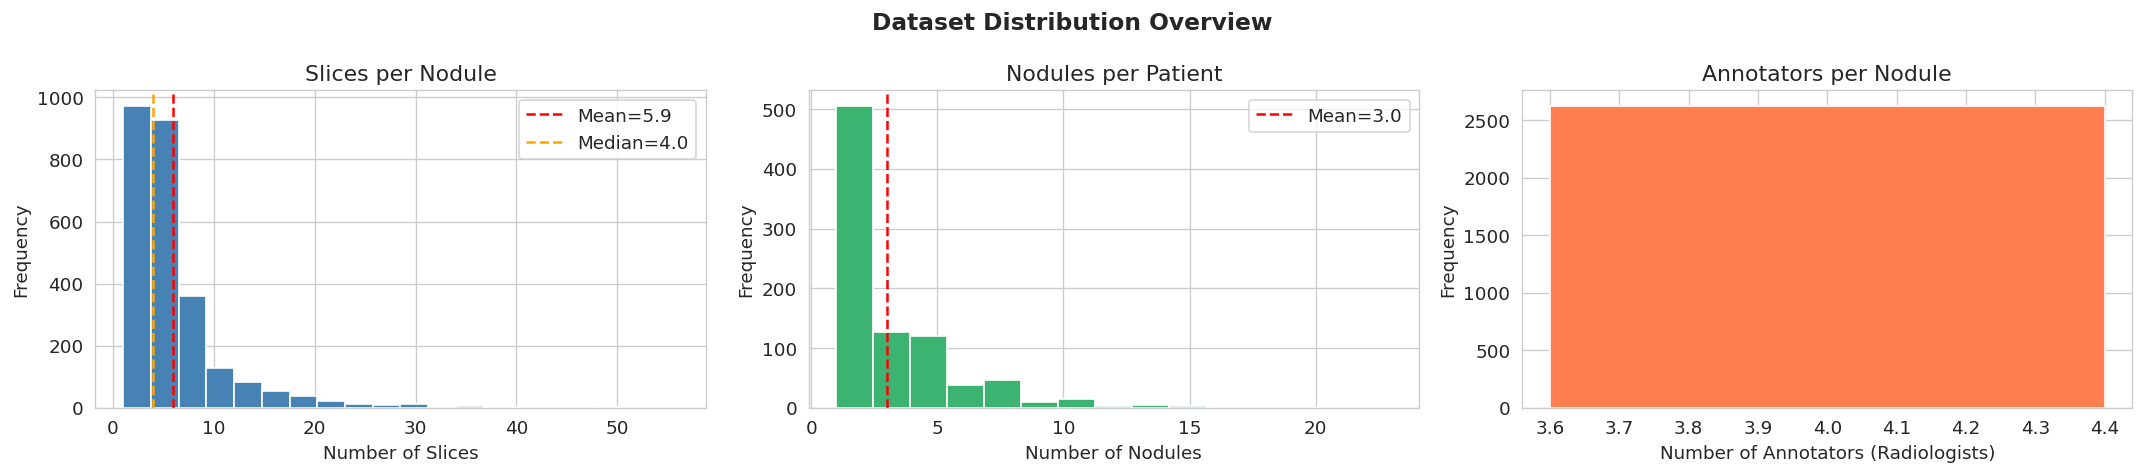

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['num_slices'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['num_slices'].mean(),   color='red',    linestyle='--', label=f"Mean={df['num_slices'].mean():.1f}")
axes[0].axvline(df['num_slices'].median(), color='orange', linestyle='--', label=f"Median={df['num_slices'].median():.1f}")
axes[0].set_title('Slices per Nodule')
axes[0].set_xlabel('Number of Slices')
axes[0].set_ylabel('Frequency')
axes[0].legend()

npp = df.groupby('patient').size()
axes[1].hist(npp, bins=15, color='mediumseagreen', edgecolor='white')
axes[1].axvline(npp.mean(), color='red', linestyle='--', label=f"Mean={npp.mean():.1f}")
axes[1].set_title('Nodules per Patient')
axes[1].set_xlabel('Number of Nodules')
axes[1].set_ylabel('Frequency')
axes[1].legend()

ann_counts = df['num_annotators'].value_counts().sort_index()
axes[2].bar(ann_counts.index, ann_counts.values, color='coral', edgecolor='white')
axes[2].set_title('Annotators per Nodule')
axes[2].set_xlabel('Number of Annotators (Radiologists)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Dataset Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

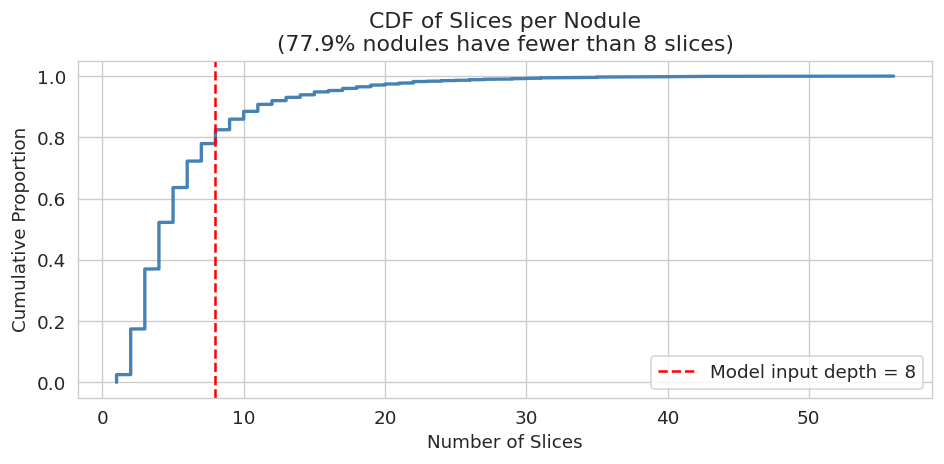

Nodules with <  8 slices: 2050 (77.9%) — need padding/dropping
Nodules with >= 8 slices: 580


In [8]:
sorted_slices = np.sort(df['num_slices'])
cdf = np.arange(1, len(sorted_slices) + 1) / len(sorted_slices)

plt.figure(figsize=(8, 4))
plt.plot(sorted_slices, cdf, color='steelblue', linewidth=2)
plt.axvline(8, color='red', linestyle='--', label='Model input depth = 8')
pct_below_8 = (df['num_slices'] < 8).mean() * 100
plt.title(f'CDF of Slices per Nodule\n({pct_below_8:.1f}% nodules have fewer than 8 slices)')
plt.xlabel('Number of Slices')
plt.ylabel('Cumulative Proportion')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Nodules with <  8 slices: {(df['num_slices'] < 8).sum()} ({pct_below_8:.1f}%) — need padding/dropping")
print(f"Nodules with >= 8 slices: {(df['num_slices'] >= 8).sum()}")

In [9]:
sample_df = df.sample(min(30, len(df)), random_state=42)

all_pixels   = []
image_means  = []
image_stds   = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Reading pixel data"):
    img_folder = os.path.join(row['nodule_path'], 'images')
    slices_to_read = random.sample(row['image_files'], min(3, len(row['image_files'])))

    for img_file in slices_to_read:
        img = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        all_pixels.extend(img.flatten().tolist())
        image_means.append(img.mean())
        image_stds.append(img.std())

all_pixels  = np.array(all_pixels)
image_means = np.array(image_means)
image_stds  = np.array(image_stds)

print(f"Total pixels sampled : {len(all_pixels):,}")
print(f"Global Mean          : {all_pixels.mean():.2f}")
print(f"Global Std           : {all_pixels.std():.2f}")
print(f"Min / Max            : {all_pixels.min()} / {all_pixels.max()}")

Reading pixel data: 100%|██████████| 30/30 [00:00<00:00, 137.04it/s]


Total pixels sampled : 1,392,640
Global Mean          : 77.79
Global Std           : 63.06
Min / Max            : 0 / 255


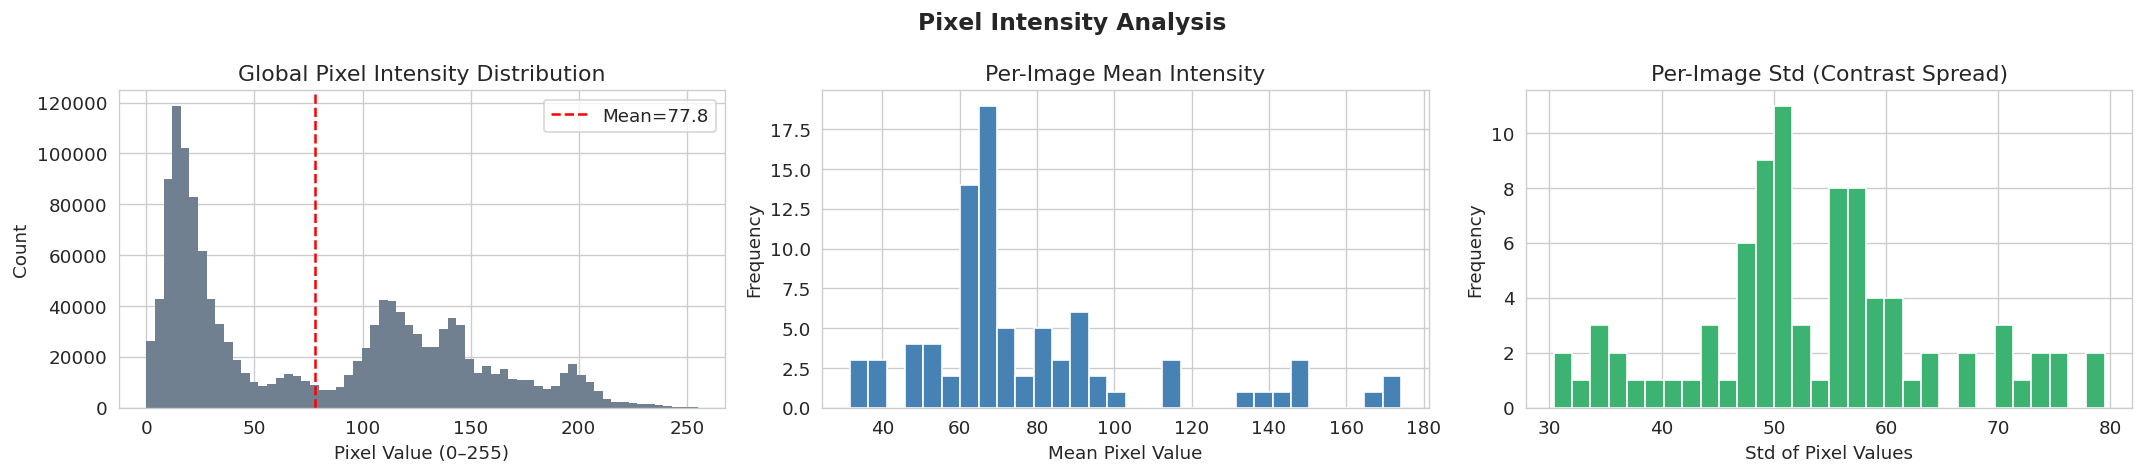

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(all_pixels, bins=64, color='slategray', edgecolor='none')
axes[0].axvline(all_pixels.mean(), color='red', linestyle='--', label=f'Mean={all_pixels.mean():.1f}')
axes[0].set_title('Global Pixel Intensity Distribution')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(image_means, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Per-Image Mean Intensity')
axes[1].set_xlabel('Mean Pixel Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(image_stds, bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Per-Image Std (Contrast Spread)')
axes[2].set_xlabel('Std of Pixel Values')
axes[2].set_ylabel('Frequency')

plt.suptitle('Pixel Intensity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
mask_areas     = []
mask_densities = []

sample_df2 = df[df['num_annotators'] > 0].sample(min(40, len(df)), random_state=42)

for _, row in tqdm(sample_df2.iterrows(), total=len(sample_df2), desc="Analysing masks"):
    img_folder     = os.path.join(row['nodule_path'], 'images')
    slices_to_read = random.sample(row['image_files'], min(3, len(row['image_files'])))

    for img_file in slices_to_read:
        img = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        combined_mask = None
        for mask_folder in row['mask_folders']:
            mask_path = os.path.join(mask_folder, img_file)
            if not os.path.exists(mask_path):
                continue
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            combined_mask = mask if combined_mask is None else np.maximum(combined_mask, mask)

        if combined_mask is not None:
            area = np.sum(combined_mask > 0)
            mask_areas.append(area)
            mask_densities.append(area / (img.shape[0] * img.shape[1]))

mask_areas     = np.array(mask_areas)
mask_densities = np.array(mask_densities)

print(f"Samples analysed      : {len(mask_areas)}")
print(f"Mean mask area (px)   : {mask_areas.mean():.1f}")
print(f"Median mask area (px) : {np.median(mask_areas):.1f}")
print(f"Mean density          : {mask_densities.mean()*100:.3f}% of image")

Analysing masks: 100%|██████████| 40/40 [00:00<00:00, 128.30it/s]

Samples analysed      : 113
Mean mask area (px)   : 96.7
Median mask area (px) : 51.0
Mean density          : 0.590% of image


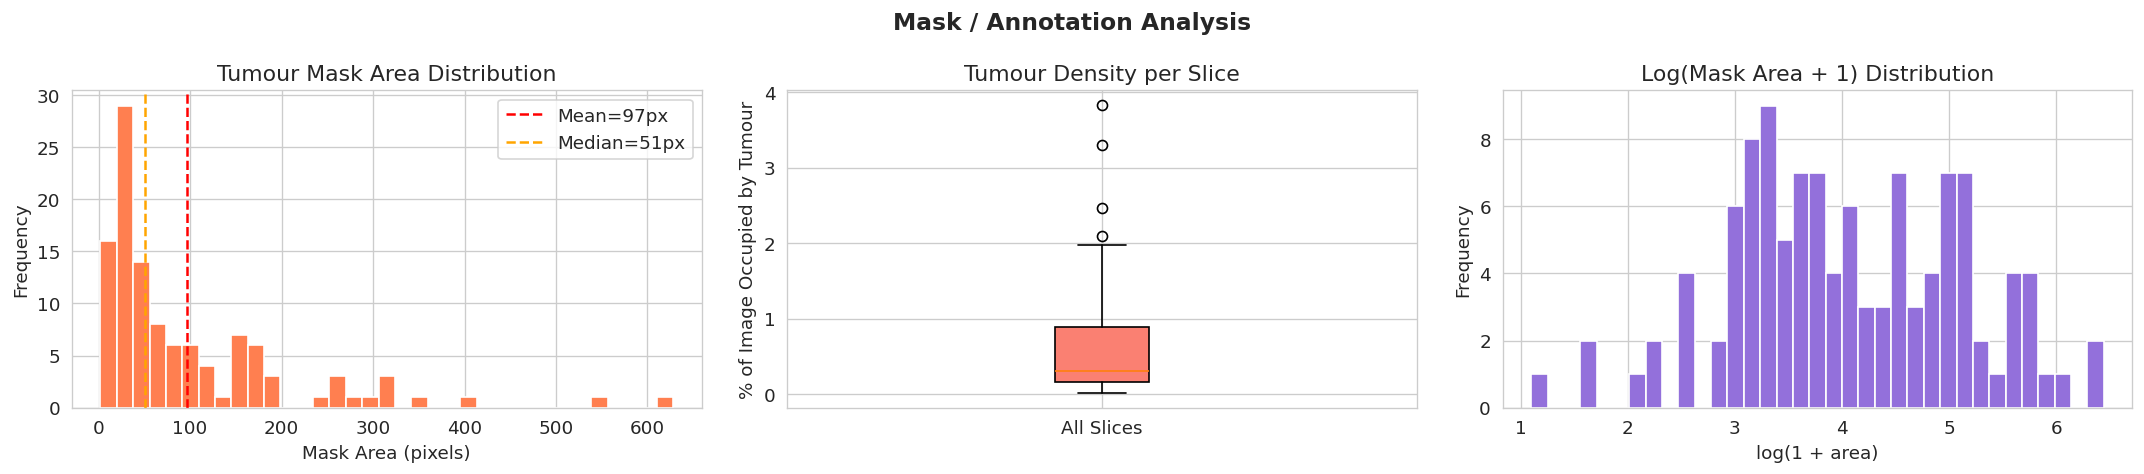

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(mask_areas, bins=35, color='coral', edgecolor='white')
axes[0].axvline(mask_areas.mean(),       color='red',    linestyle='--', label=f'Mean={mask_areas.mean():.0f}px')
axes[0].axvline(np.median(mask_areas),   color='orange', linestyle='--', label=f'Median={np.median(mask_areas):.0f}px')
axes[0].set_title('Tumour Mask Area Distribution')
axes[0].set_xlabel('Mask Area (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(mask_densities * 100, vert=True, patch_artist=True,
                boxprops=dict(facecolor='salmon'))
axes[1].set_title('Tumour Density per Slice')
axes[1].set_ylabel('% of Image Occupied by Tumour')
axes[1].set_xticklabels(['All Slices'])

axes[2].hist(np.log1p(mask_areas), bins=35, color='mediumpurple', edgecolor='white')
axes[2].set_title('Log(Mask Area + 1) Distribution')
axes[2].set_xlabel('log(1 + area)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Mask / Annotation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
def pairwise_iou(masks):
    ious = []
    n = len(masks)
    for i in range(n):
        for j in range(i + 1, n):
            m1 = masks[i] > 0
            m2 = masks[j] > 0
            inter = np.logical_and(m1, m2).sum()
            union = np.logical_or(m1, m2).sum()
            if union == 0:
                continue
            ious.append(inter / union)
    return np.mean(ious) if ious else None


iou_scores = []
multi_df = df[df['num_annotators'] >= 2].sample(min(30, (df['num_annotators'] >= 2).sum()), random_state=42)

for _, row in tqdm(multi_df.iterrows(), total=len(multi_df), desc="Computing IoU"):
    img_folder     = os.path.join(row['nodule_path'], 'images')
    slices_to_read = random.sample(row['image_files'], min(2, len(row['image_files'])))

    for img_file in slices_to_read:
        per_annotator = []
        for mask_folder in row['mask_folders']:
            mask_path = os.path.join(mask_folder, img_file)
            if not os.path.exists(mask_path):
                continue
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                per_annotator.append(mask)

        if len(per_annotator) >= 2:
            iou = pairwise_iou(per_annotator)
            if iou is not None:
                iou_scores.append(iou)

iou_scores = np.array(iou_scores)
print(f"Slices analysed       : {len(iou_scores)}")
print(f"Mean pairwise IoU     : {iou_scores.mean():.3f}")
print(f"Std pairwise IoU      : {iou_scores.std():.3f}")
print(f"% slices IoU > 0.5   : {(iou_scores > 0.5).mean()*100:.1f}%")

Computing IoU: 100%|██████████| 30/30 [00:00<00:00, 353.13it/s]

Slices analysed       : 59
Mean pairwise IoU     : 0.231
Std pairwise IoU      : 0.264
% slices IoU > 0.5   : 18.6%


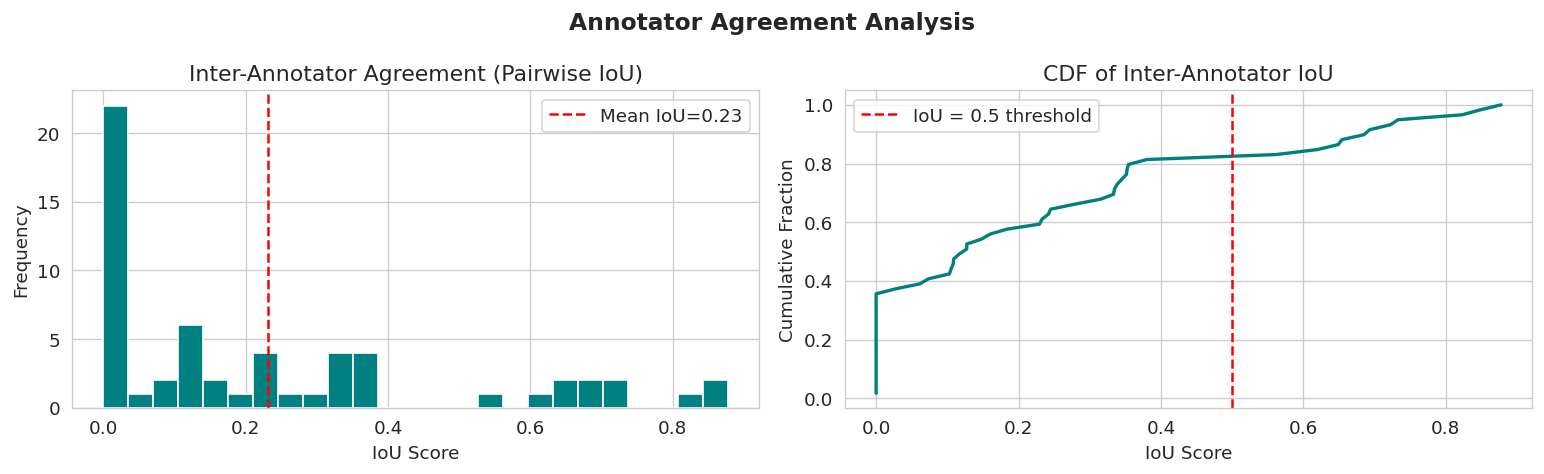

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(iou_scores, bins=25, color='teal', edgecolor='white')
axes[0].axvline(iou_scores.mean(), color='red', linestyle='--', label=f'Mean IoU={iou_scores.mean():.2f}')
axes[0].set_title('Inter-Annotator Agreement (Pairwise IoU)')
axes[0].set_xlabel('IoU Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sorted_iou = np.sort(iou_scores)
cdf_iou    = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1].plot(sorted_iou, cdf_iou, color='teal', linewidth=2)
axes[1].axvline(0.5, color='red', linestyle='--', label='IoU = 0.5 threshold')
axes[1].set_title('CDF of Inter-Annotator IoU')
axes[1].set_xlabel('IoU Score')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].legend()

plt.suptitle('Annotator Agreement Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

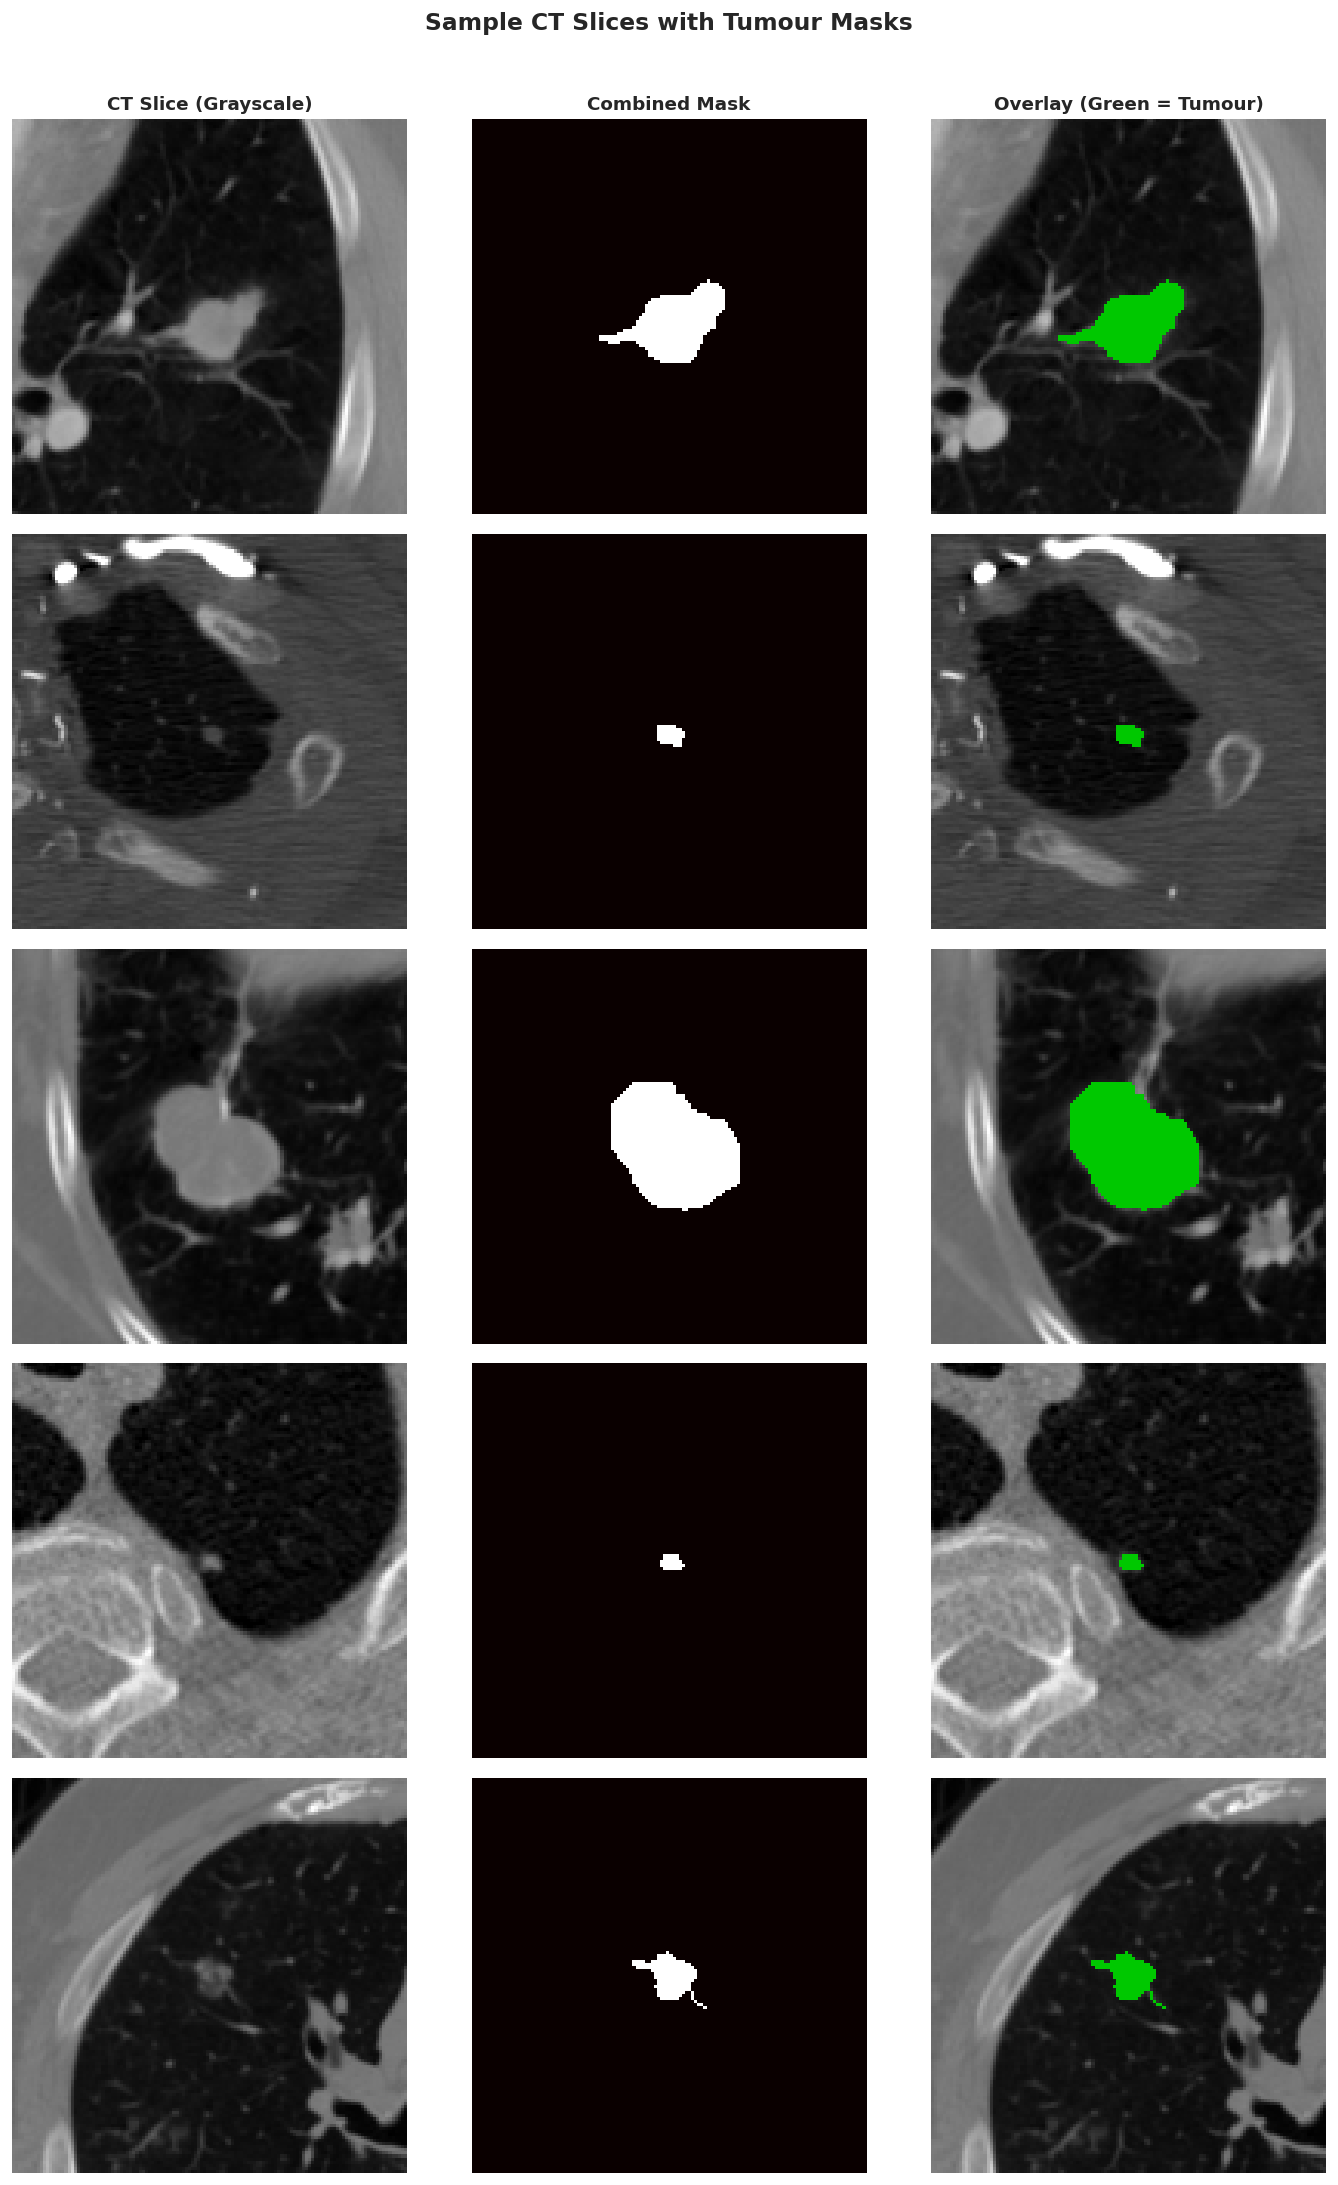

In [15]:
sample_rows = df[df['num_annotators'] > 0].sample(5, random_state=7)

fig, axes = plt.subplots(5, 3, figsize=(12, 18))
col_titles = ['CT Slice (Grayscale)', 'Combined Mask', 'Overlay (Green = Tumour)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=11)

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    img_folder = os.path.join(row['nodule_path'], 'images')
    mid        = len(row['image_files']) // 2
    img_file   = row['image_files'][mid]

    img = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)

    combined_mask = None
    for mask_folder in row['mask_folders']:
        mask_path = os.path.join(mask_folder, img_file)
        if not os.path.exists(mask_path):
            continue
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            combined_mask = mask if combined_mask is None else np.maximum(combined_mask, mask)

    if img is None or combined_mask is None:
        continue

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[combined_mask > 0, 0] = 0
    overlay[combined_mask > 0, 1] = 200
    overlay[combined_mask > 0, 2] = 0

    axes[row_idx][0].imshow(img, cmap='gray')
    axes[row_idx][0].set_ylabel(f"{row['patient']}\n{row['nodule']}", fontsize=8)
    axes[row_idx][1].imshow(combined_mask, cmap='hot')
    axes[row_idx][2].imshow(overlay)

    for ax in axes[row_idx]:
        ax.axis('off')

plt.suptitle('Sample CT Slices with Tumour Masks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

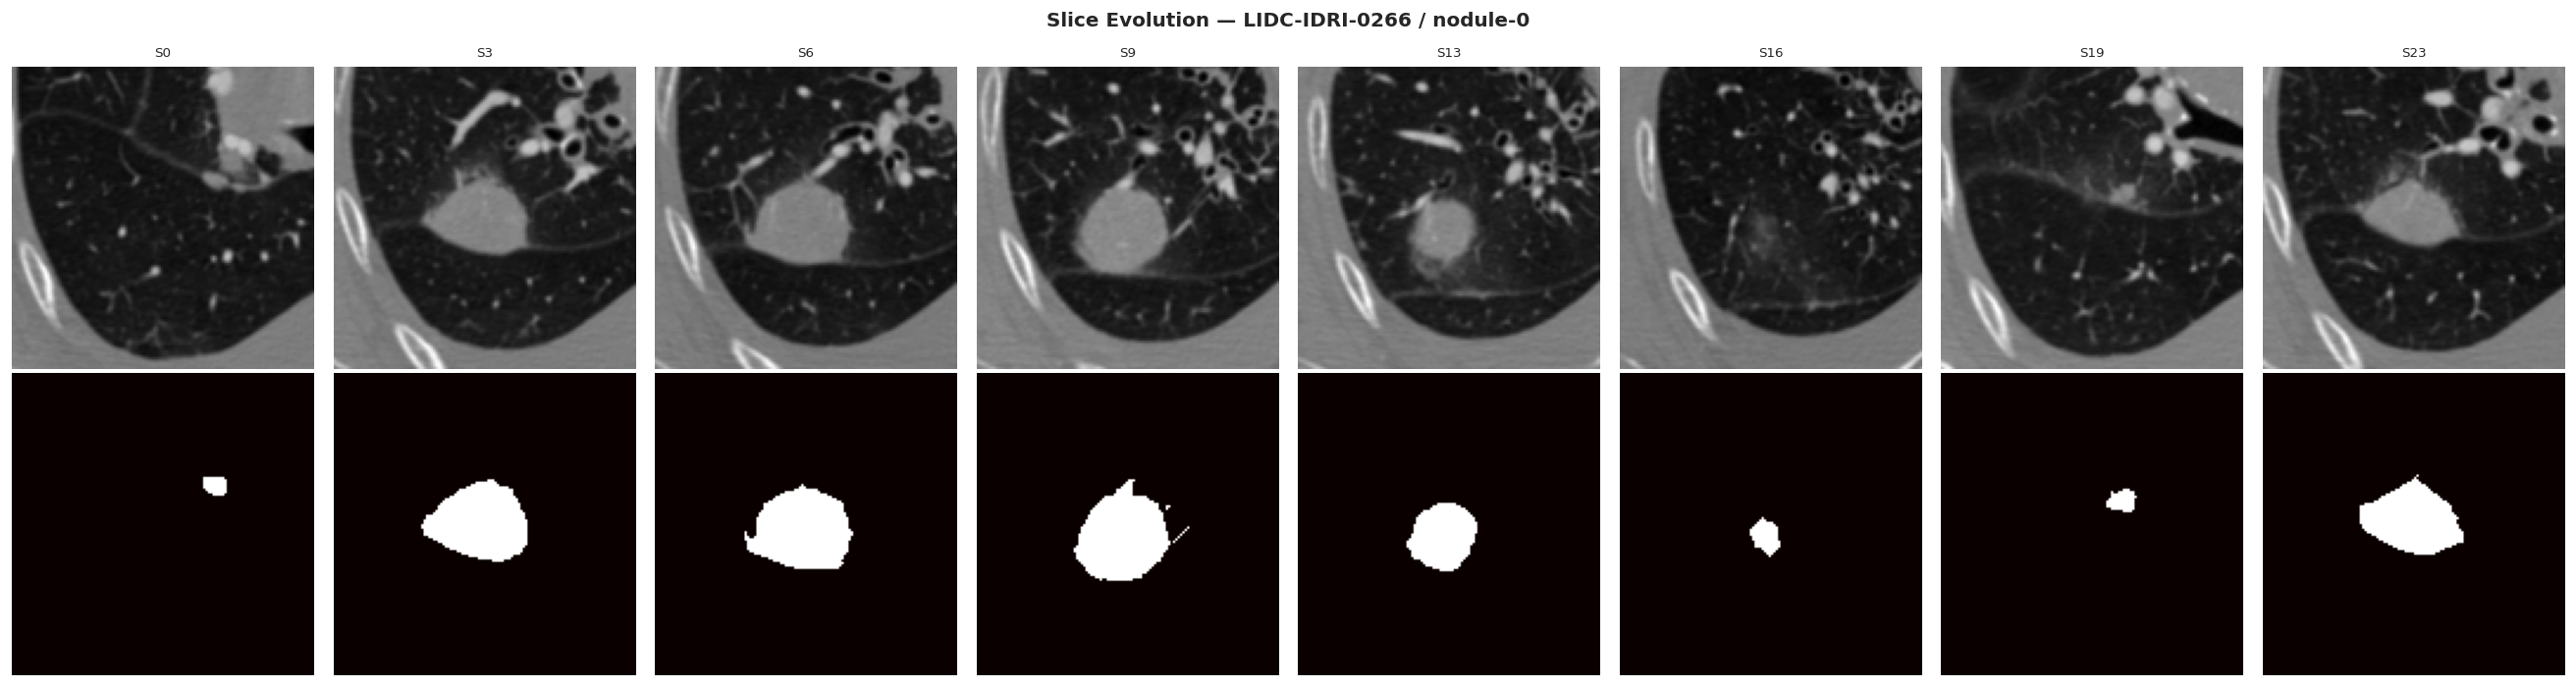

In [16]:
row     = df[df['num_slices'] >= 8].sample(1, random_state=3).iloc[0]
img_folder  = os.path.join(row['nodule_path'], 'images')
num_slices  = len(row['image_files'])
indices     = np.linspace(0, num_slices - 1, 8, dtype=int)

fig, axes = plt.subplots(2, 8, figsize=(22, 6))
fig.suptitle(f"Slice Evolution — {row['patient']} / {row['nodule']}", fontsize=12, fontweight='bold')

for col, idx in enumerate(indices):
    img_file = row['image_files'][idx]
    img      = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)

    combined_mask = None
    for mask_folder in row['mask_folders']:
        mask_path = os.path.join(mask_folder, img_file)
        if os.path.exists(mask_path):
            m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if m is not None:
                combined_mask = m if combined_mask is None else np.maximum(combined_mask, m)

    axes[0][col].imshow(img, cmap='gray')
    axes[0][col].set_title(f'S{idx}', fontsize=8)
    axes[0][col].axis('off')

    if combined_mask is not None:
        axes[1][col].imshow(combined_mask, cmap='hot')
    axes[1][col].axis('off')

axes[0][0].set_ylabel('CT',   fontsize=9)
axes[1][0].set_ylabel('Mask', fontsize=9)
plt.tight_layout()
plt.show()

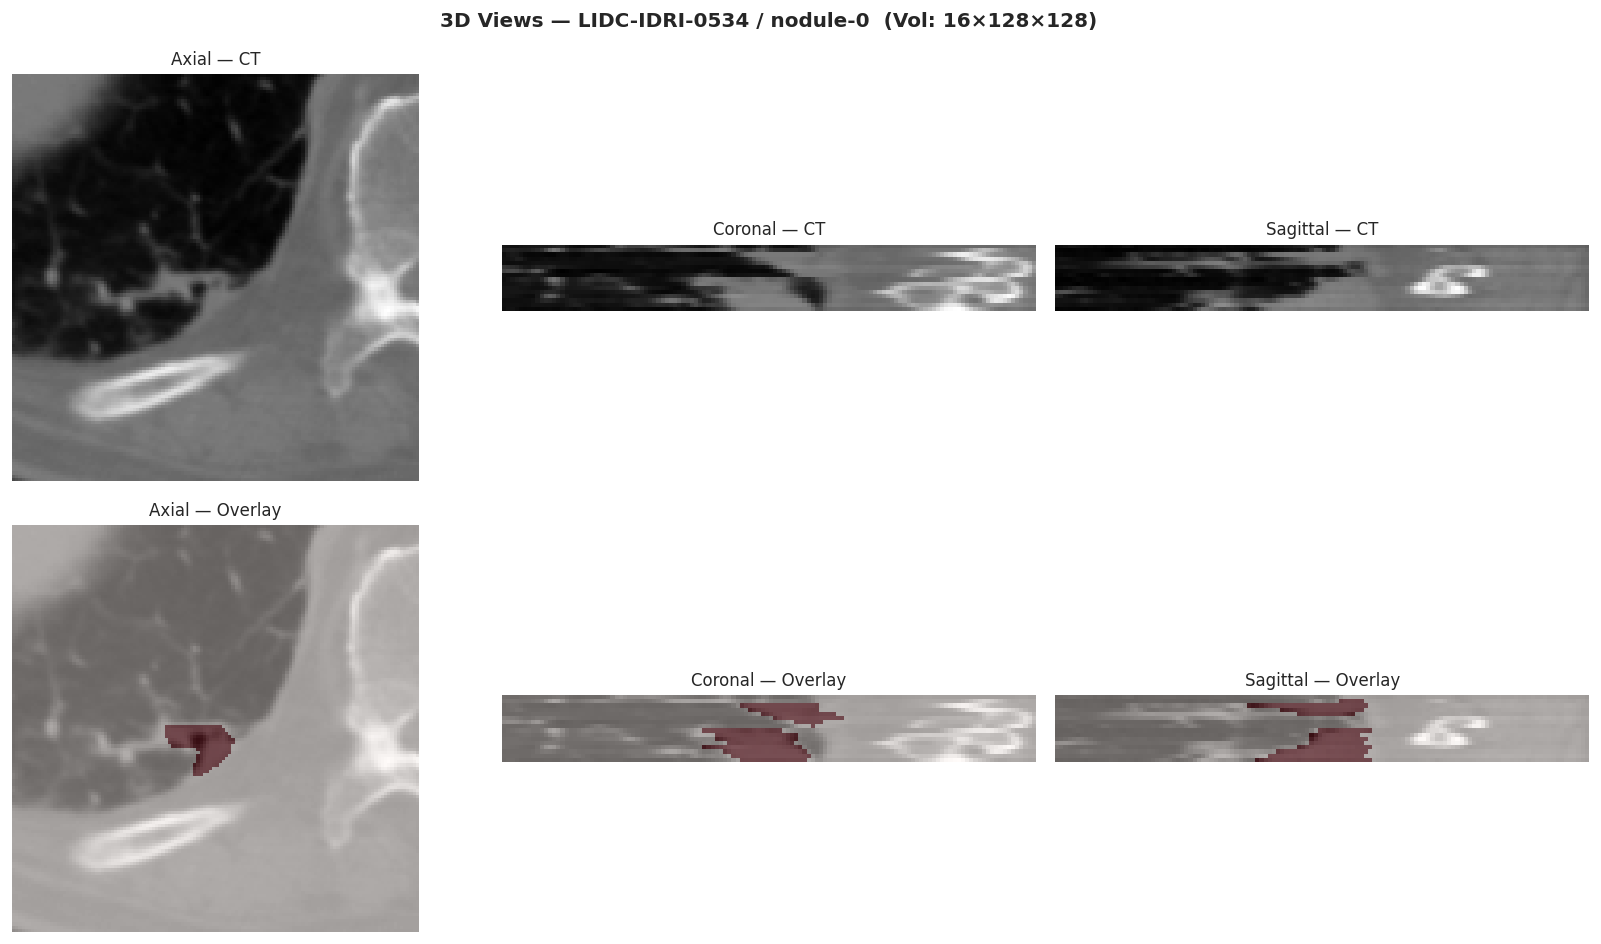

In [17]:
row = df[df['num_slices'] >= 8].sample(1, random_state=10).iloc[0]

img_folder = os.path.join(row['nodule_path'], 'images')
vol, mask_vol = [], []

for img_file in row['image_files']:
    img = cv2.imread(os.path.join(img_folder, img_file), cv2.IMREAD_GRAYSCALE)
    img_r = cv2.resize(img, (128, 128)) if img is not None else np.zeros((128,128), dtype=np.uint8)
    vol.append(img_r)

    combined_mask = None
    for mask_folder in row['mask_folders']:
        mask_path = os.path.join(mask_folder, img_file)
        if os.path.exists(mask_path):
            m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if m is not None:
                mr = cv2.resize(m, (128, 128))
                combined_mask = mr if combined_mask is None else np.maximum(combined_mask, mr)
    mask_vol.append(combined_mask if combined_mask is not None else np.zeros((128,128), dtype=np.uint8))

vol      = np.array(vol)       # (D, H, W)
mask_vol = np.array(mask_vol)
D, H, W  = vol.shape
mid_d, mid_h, mid_w = D//2, H//2, W//2

views = [
    (vol[mid_d],       mask_vol[mid_d],       'Axial'),
    (vol[:, mid_h, :], mask_vol[:, mid_h, :], 'Coronal'),
    (vol[:, :, mid_w], mask_vol[:, :, mid_w], 'Sagittal'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, (ct_s, mask_s, title) in enumerate(views):
    axes[0][col].imshow(ct_s, cmap='gray')
    axes[0][col].set_title(f'{title} — CT', fontsize=10)
    axes[0][col].axis('off')

    axes[1][col].imshow(ct_s, cmap='gray')
    axes[1][col].imshow(mask_s, cmap='Reds', alpha=0.4)
    axes[1][col].set_title(f'{title} — Overlay', fontsize=10)
    axes[1][col].axis('off')

plt.suptitle(f'3D Views — {row["patient"]} / {row["nodule"]}  (Vol: {D}×{H}×{W})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

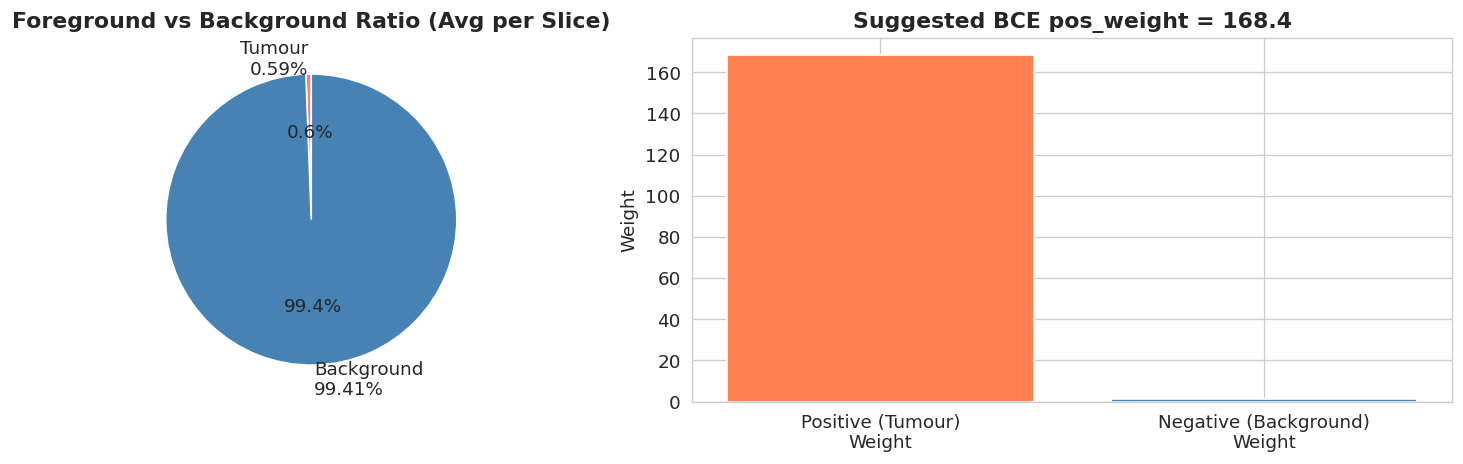

Class imbalance ratio  : 168.4:1  (background:foreground)
Recommended pos_weight : 168.37  →  nn.BCEWithLogitsLoss(pos_weight=torch.tensor([168.37]))


In [18]:
mean_density     = mask_densities.mean()
background_ratio = 1 - mean_density
pos_weight       = background_ratio / mean_density

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].pie(
    [mean_density * 100, background_ratio * 100],
    labels=[f'Tumour\n{mean_density*100:.2f}%', f'Background\n{background_ratio*100:.2f}%'],
    colors=['salmon', 'steelblue'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Foreground vs Background Ratio (Avg per Slice)', fontweight='bold')

axes[1].bar(
    ['Positive (Tumour)\nWeight', 'Negative (Background)\nWeight'],
    [pos_weight, 1.0],
    color=['coral', 'steelblue'], edgecolor='white'
)
axes[1].set_title(f'Suggested BCE pos_weight = {pos_weight:.1f}', fontweight='bold')
axes[1].set_ylabel('Weight')

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio  : {pos_weight:.1f}:1  (background:foreground)")
print(f"Recommended pos_weight : {pos_weight:.2f}  →  nn.BCEWithLogitsLoss(pos_weight=torch.tensor([{pos_weight:.2f}]))")

In [19]:
below_8 = (df['num_slices'] < 8).sum()
above_8 = (df['num_slices'] >= 8).sum()

print(f"Input shape expected        : (N, 8, 128, 128, 1)")
print(f"Nodules with >= 8 slices    : {above_8}  ({above_8/len(df)*100:.1f}%)")
print(f"Nodules with <  8 slices    : {below_8}  ({below_8/len(df)*100:.1f}%) → pad or drop")

total_windows = df['num_slices'].apply(lambda s: max(1, s - 7)).sum()
print(f"Est. total sliding windows  : {total_windows:,}  (stride=1, depth=8)")

Input shape expected        : (N, 8, 128, 128, 1)
Nodules with >= 8 slices    : 580  (22.1%)
Nodules with <  8 slices    : 2050  (77.9%) → pad or drop
Est. total sliding windows  : 5,635  (stride=1, depth=8)


In [20]:
summary = {
    "Total Patients":            df['patient'].nunique(),
    "Total Valid Nodules":       len(df),
    "Total CT Slices":           int(df['num_slices'].sum()),
    "Avg Slices/Nodule":         round(df['num_slices'].mean(), 2),
    "Median Slices/Nodule":      int(df['num_slices'].median()),
    "Avg Annotators/Nodule":     round(df['num_annotators'].mean(), 2),
    "Mean Pixel Intensity":      round(float(all_pixels.mean()), 2),
    "Mean Pixel Std":            round(float(all_pixels.std()), 2),
    "Mean Mask Area (px)":       round(float(mask_areas.mean()), 2),
    "Mean Inter-Annotator IoU":  round(float(iou_scores.mean()), 3),
    "Tumour Density (%)":        round(float(mean_density * 100), 3),
    "Class Imbalance Ratio":     round(float(pos_weight), 1),
    "Nodules with >= 8 slices":  int(above_8),
    "Est. Training Windows":     int(total_windows),
}

summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])
display(summary_df.style
    .set_caption("EDA Summary")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14pt'), ('font-weight', 'bold')]}])
)

,Metric,Value
0,Total Patients,875.000000
1,Total Valid Nodules,2630.000000
2,Total CT Slices,15548.000000
3,Avg Slices/Nodule,5.910000
4,Median Slices/Nodule,4.000000
5,Avg Annotators/Nodule,4.000000
6,Mean Pixel Intensity,77.790000
7,Mean Pixel Std,63.060000
8,Mean Mask Area (px),96.730000
9,Mean Inter-Annotator IoU,0.231000
